Fine-Tune MentalBERT Classifier

**Project:** AI Mental Health Support Chatbot  
**Goal:** Fine-tune `mentalbert-base-uncased` on the Phase 2 train/validation/test splits and compare against the LinearSVC baseline



## 1. Environment Setup (Colab)
Mount Google Drive, verify GPU availability, clone the repository, and install dependencies.

In [ ]:
import os
import sys
import json
import torch

IN_COLAB = "google.colab" in sys.modules

print(f"Running in Colab: {IN_COLAB}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Running in Colab: True
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# --- Colab local paths ---
REPO_URL = "https://github.com/ArihantJain007/SafeSpaceAI.git"
PROJECT_DIR = "/content/Mental_health-bot"

import os

if not os.path.isdir(PROJECT_DIR):
    !git clone {REPO_URL} {PROJECT_DIR}
else:
    !cd {PROJECT_DIR} && git pull

%cd {PROJECT_DIR}

SPLITS_DIR = os.path.join(PROJECT_DIR, "data/processed/splits")
OUTPUT_DIR = os.path.join(PROJECT_DIR, "models/mental_bert")

os.makedirs(SPLITS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Splits dir:", SPLITS_DIR)
print("Output dir:", OUTPUT_DIR)

Cloning into '/content/Mental_health-bot'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 45 (delta 16), reused 39 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 76.83 KiB | 9.60 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/Mental_health-bot
Project dir: /content/Mental_health-bot
Splits dir: /content/Mental_health-bot/data/processed/splits
Output dir: /content/Mental_health-bot/models/mental_bert


In [ ]:
!ls src/models

baseline.py  distilbert_classifier.py  __init__.py  mental_bert_classifier.py


In [ ]:
if not os.path.isdir(PROJECT_DIR):
    !git clone {REPO_URL} {PROJECT_DIR}
else:
    !cd {PROJECT_DIR} && git pull

%cd {PROJECT_DIR}
!pip install -q -r requirements.txt

Already up to date.
/content/Mental_health-bot
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.5/947.5 kB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.1 MB/s eta 0:00:00


In [ ]:
import os

SPLITS_DIR = "/content/Mental_health-bot/data/processed/splits"

print("Files in splits directory:")
print(os.listdir(SPLITS_DIR))

Files in splits directory:
[]


## 2. Verify Phase 2 Splits on Google Drive
Upload the **exact** Phase 2 split files to Drive if they are not already present:
- `train.csv` (40,844 rows)
- `validation.csv` (5,105 rows)
- `test.csv` (5,106 rows)

Do **not** regenerate splits in Colab — use the persisted Phase 2 files.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv
Saving validation.csv to validation.csv


In [ ]:
import os
import shutil

PROJECT_DIR = "/content/Mental_health-bot"
SPLITS_DIR = os.path.join(PROJECT_DIR, "data/processed/splits")

os.makedirs(SPLITS_DIR, exist_ok=True)

for fname in ["train.csv", "validation.csv", "test.csv"]:
    src = os.path.join(PROJECT_DIR, fname)
    dst = os.path.join(SPLITS_DIR, fname)

    if not os.path.exists(src):
        raise FileNotFoundError(f"Could not find {src}")

    shutil.copy2(src, dst)

print("Copied all split files.")

Copied all split files.


In [ ]:
import pandas as pd
import os

for fname in ["train.csv", "validation.csv", "test.csv"]:
    path = os.path.join(SPLITS_DIR, fname)
    df = pd.read_csv(path)
    print(f"{fname}: {df.shape}")

train.csv: (40844, 2)
validation.csv: (5105, 2)
test.csv: (5106, 2)


## 3. Optional Local Smoke Test (CPU-safe)
This lightweight check validates tokenizer, model init, class weights, forward pass, weighted loss, checkpoint save/load, and sample inference. It does **not** run full training.

In [ ]:
!python -m src.models.distilbert_classifier \
    --smoke-test \
    --data-dir "{SPLITS_DIR}" \
    --output-dir "{OUTPUT_DIR}"

## 4. Full DistilBERT Fine-Tuning (CUDA GPU Required)
Trains for 3 epochs with:
- `max_length=256`
- class-weighted `CrossEntropyLoss` (train labels only)
- validation **Macro F1** checkpoint selection
- checkpoint save/resume support
- **single** held-out test evaluation after model selection

Artifacts are written to Google Drive under `models/distilbert/`:
- `checkpoints/`
- `best_model/`
- `tokenizer/`
- `label_mapping.json`
- `metadata.json`
- `plots/`

In [ ]:
from huggingface_hub import login

login()

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "mental/mental-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("MentalBERT tokenizer loaded successfully.")

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

MentalBERT tokenizer loaded successfully.


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=7
)

print("MentalBERT model loaded successfully.")
print("Number of labels:", model.config.num_labels)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

MentalBERT model loaded successfully.
Number of labels: 7


In [ ]:
!python -m src.models.mental_bert_classifier --smoke-test

RUNNING LOCAL SMOKE TEST (CPU Micro-Batch Verification - MentalBERT)
1. Verifying Environment & Packages:
   - Python version: 3.13.15
   - PyTorch version: 2.11.0+cu128
   - CUDA Available: True

2. Verified Data Splits:
   - Train shape: (40844, 2) (Expected: 40844)
   - Val shape:   (5105, 2) (Expected: 5105)
   - Test shape:  (5106, 2) (Expected: 5106)

3. Canonical Label Mapping:
    {'Anxiety': 0, 'Bipolar': 1, 'Depression': 2, 'Normal': 3, 'Personality disorder': 4, 'Stress': 5, 'Suicidal': 6}

4. Class Weights Calculated from Train Labels:
   - Anxiety             : 2.0162
   - Bipolar             : 2.9160
   - Depression          : 0.4837
   - Normal              : 0.4548
   - Personality disorder: 8.1492
   - Stress              : 3.1815
   - Suicidal            : 0.6859

5. Initializing Tokenizer & MentalBERT Model...
Loading weights: 100% 197/197 [00:00<00:00, 24527.37it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key   

In [ ]:
warmup_ratio=0.1
eval_strategy="epoch"
save_strategy="epoch"
load_best_model_at_end=True
metric_for_best_model="macro_f1"

In [ ]:
from transformers import TrainingArguments
import inspect

print(inspect.signature(TrainingArguments))

(output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_compile_

In [ ]:
%cd /content/Mental_health-bot
!git pull

/content/Mental_health-bot
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 564 bytes | 62.00 KiB/s, done.
From https://github.com/ArihantJain007/Mental_health-bot
   5a847ec..a79148c  main       -> origin/main
Updating 5a847ec..a79148c
Fast-forward
 src/models/mental_bert_classifier.py | 11 +++++++++--
 1 file changed, 9 insertions(+), 2 deletions(-)


In [ ]:
from transformers import TrainingArguments

test_args = TrainingArguments(
    output_dir="/content/test_training_args",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    seed=42,
    logging_steps=100,
    fp16=True,
    save_total_limit=3,
    report_to="none",
)

print("TrainingArguments created successfully.")

TrainingArguments created successfully.


In [ ]:
!grep -n "warmup\|logging_dir" src/models/mental_bert_classifier.py

470:    warmup_steps = int(total_training_steps * 0.1)
473:    print(f"Warmup steps: {warmup_steps}")
482:        warmup_steps=warmup_steps,


In [ ]:
!python -m src.models.mental_bert_classifier --smoke-test

RUNNING LOCAL SMOKE TEST (CPU Micro-Batch Verification - MentalBERT)
1. Verifying Environment & Packages:
   - Python version: 3.13.15
   - PyTorch version: 2.11.0+cu128
   - CUDA Available: True

2. Verified Data Splits:
   - Train shape: (40844, 2) (Expected: 40844)
   - Val shape:   (5105, 2) (Expected: 5105)
   - Test shape:  (5106, 2) (Expected: 5106)

3. Canonical Label Mapping:
    {'Anxiety': 0, 'Bipolar': 1, 'Depression': 2, 'Normal': 3, 'Personality disorder': 4, 'Stress': 5, 'Suicidal': 6}

4. Class Weights Calculated from Train Labels:
   - Anxiety             : 2.0162
   - Bipolar             : 2.9160
   - Depression          : 0.4837
   - Normal              : 0.4548
   - Personality disorder: 8.1492
   - Stress              : 3.1815
   - Suicidal            : 0.6859

5. Initializing Tokenizer & MentalBERT Model...
Loading weights: 100% 197/197 [00:00<00:00, 13818.51it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key   

In [ ]:
!python -m src.models.mental_bert_classifier --full-train \
  --data-dir /content/Mental_health-bot/data/processed/splits \
  --output-dir /content/Mental_health-bot/models/mental_bert \
  --num-epochs 3 \
  --batch-size 8 \
  --lr 2e-5

PHASE 3 — MENTALBERT FULL FINE-TUNING PIPELINE
CUDA GPU Detected: Tesla T4
PyTorch Version:  2.11.0+cu128
Loading weights: 100% 197/197 [00:00<00:00, 23826.46it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: mental/mental-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight         

In [26]:
import os

MODEL_DIR = "/content/Mental_health-bot/models/mental_bert"

print("MentalBERT artifacts:")
for item in os.listdir(MODEL_DIR):
    print(" -", item)

MentalBERT artifacts:
 - plots
 - best_model
 - checkpoints
 - tokenizer
 - label_mapping.json
 - smoke_test_model
 - metadata.json


In [27]:
import json

metadata_path = "/content/Mental_health-bot/models/mental_bert/metadata.json"

with open(metadata_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("=== MentalBERT Results ===")

print("\nBest Validation Metrics:")
print("Macro-F1:", metadata["validation_best_metrics"]["macro_f1"])
print("Accuracy:", metadata["validation_best_metrics"]["accuracy"])

print("\nFinal Test Metrics:")
print("Macro-F1:", metadata["test_metrics"]["macro_f1"])
print("Accuracy:", metadata["test_metrics"]["accuracy"])
print("Weighted F1:", metadata["test_metrics"]["weighted_f1"])

=== MentalBERT Results ===

Best Validation Metrics:
Macro-F1: 0.8146602121689916
Accuracy: 0.8374142997061704

Final Test Metrics:
Macro-F1: 0.8008539552470444
Accuracy: 0.836075205640423
Weighted F1: 0.8366941635095245


In [28]:
print("=== Per-Class Test Metrics ===")

per_class = metadata["test_metrics"]["per_class"]

for label, metrics in per_class.items():
    print(
        f"{label:22s} "
        f"Precision={metrics['precision']:.4f}  "
        f"Recall={metrics['recall']:.4f}  "
        f"F1={metrics['f1']:.4f}  "
        f"Support={metrics['support']}"
    )

=== Per-Class Test Metrics ===
Anxiety                Precision=0.8753  Recall=0.8729  F1=0.8741  Support=362
Bipolar                Precision=0.8595  Recall=0.8320  F1=0.8455  Support=250
Depression             Precision=0.8151  Recall=0.7513  F1=0.7819  Support=1508
Normal                 Precision=0.9649  Recall=0.9595  F1=0.9622  Support=1604
Personality disorder   Precision=0.6875  Recall=0.6180  F1=0.6509  Support=89
Stress                 Precision=0.7027  Recall=0.7948  F1=0.7459  Support=229
Suicidal               Precision=0.7091  Recall=0.7857  F1=0.7454  Support=1064


In [29]:
import os

plots_dir = "/content/Mental_health-bot/models/mental_bert/plots"

print(os.listdir(plots_dir))

['cm_val_mental_bert.png', 'cm_test_mental_bert.png']


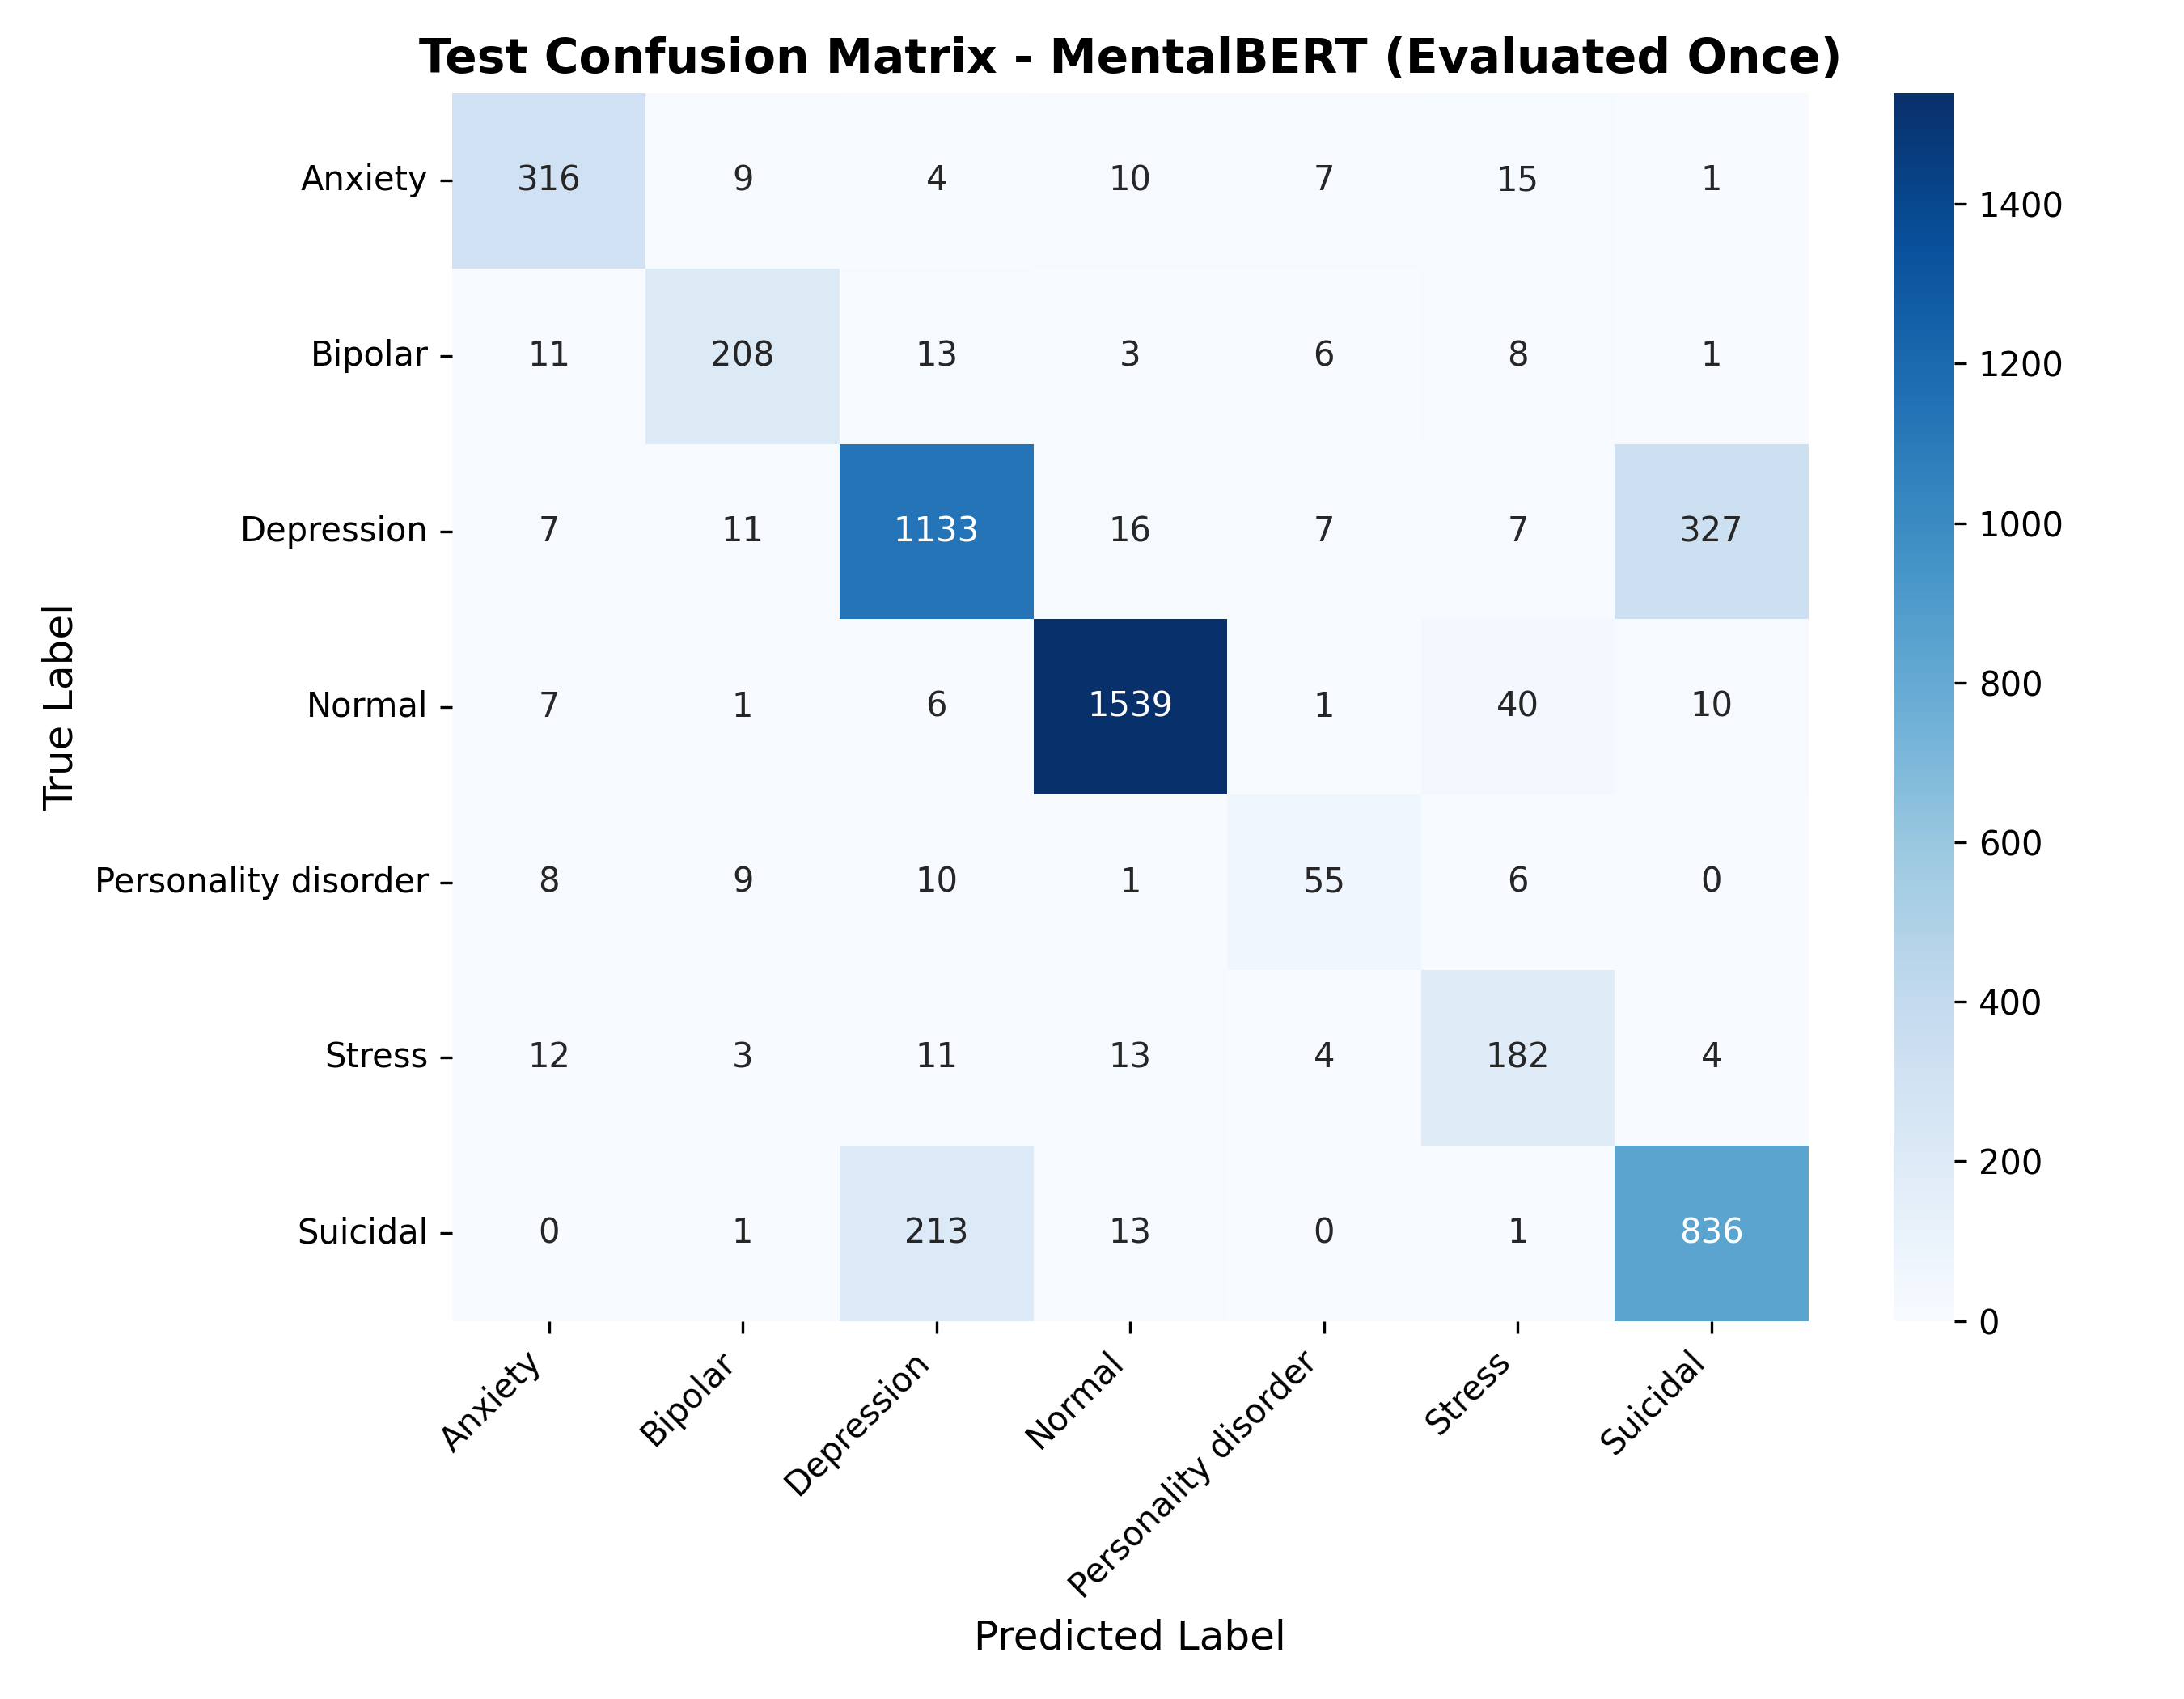

In [30]:
from IPython.display import Image, display

display(
    Image(
        filename="/content/Mental_health-bot/models/mental_bert/plots/cm_test_mental_bert.png"
    )
)

In [33]:
%cd /content/Mental_health-bot

/content/Mental_health-bot


In [34]:
!git status


On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	test.csv
	train.csv
	validation.csv

nothing added to commit but untracked files present (use "git add" to track)


In [35]:
!git add notebooks/04_mental_bert_classifier.ipynb
!git add src/models/mental_bert_classifier.py
!git add models/mental_bert/plots
!git add models/mental_bert/label_mapping.json
!git add models/mental_bert/metadata.json

The following paths are ignored by one of your .gitignore files:
models
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
The following paths are ignored by one of your .gitignore files:
models
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
The following paths are ignored by one of your .gitignore files:
models
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"


In [36]:
!git add -f models/mental_bert/plots
!git add -f models/mental_bert/label_mapping.json
!git add -f models/mental_bert/metadata.json

In [37]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   models/mental_bert/label_mapping.json
	new file:   models/mental_bert/metadata.json
	new file:   models/mental_bert/plots/cm_test_mental_bert.png
	new file:   models/mental_bert/plots/cm_val_mental_bert.png

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	test.csv
	train.csv
	validation.csv



In [38]:
!git commit -m "Add MentalBERT evaluation results"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@cc1fd8c2ec7a.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [39]:
!git config --global user.name "Arihant Jain"
!git config --global user.email "jain.arihant2305@gmail.com"

In [40]:
!git commit -m "Add MentalBERT evaluation results"
!git push origin main

[main 60009f3] Add MentalBERT evaluation results
 4 files changed, 295 insertions(+)
 create mode 100644 models/mental_bert/label_mapping.json
 create mode 100644 models/mental_bert/metadata.json
 create mode 100644 models/mental_bert/plots/cm_test_mental_bert.png
 create mode 100644 models/mental_bert/plots/cm_val_mental_bert.png
fatal: could not read Username for 'https://github.com': No such device or address


In [41]:
!git remote -v

origin	https://github.com/ArihantJain007/Mental_health-bot.git (fetch)
origin	https://github.com/ArihantJain007/Mental_health-bot.git (push)


In [42]:
!git remote set-url origin https://github.com/ArihantJain007/SafeSpaceAI.git

In [43]:
!git remote -v

origin	https://github.com/ArihantJain007/SafeSpaceAI.git (fetch)
origin	https://github.com/ArihantJain007/SafeSpaceAI.git (push)


In [44]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address


In [45]:
!git config --global credential.helper "cache --timeout=3600"

In [46]:
import subprocess
from getpass import getpass

token = getpass("Enter your GitHub Personal Access Token: ")

credential = (
    "protocol=https\n"
    "host=github.com\n"
    "username=ArihantJain007\n"
    f"password={token}\n\n"
)

subprocess.run(
    ["git", "credential", "approve"],
    input=credential,
    text=True,
    check=True
)

print("GitHub credential cached.")

Enter your GitHub Personal Access Token: ··········
GitHub credential cached.


In [47]:
!git push origin main

Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (8/8), done.
Writing objects: 100% (9/9), 408.95 KiB | 11.68 MiB/s, done.
Total 9 (delta 1), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (1/1), completed with 1 local object.
To https://github.com/ArihantJain007/SafeSpaceAI.git
   a79148c..60009f3  main -> main
